In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
benjaminkz_places365_path = kagglehub.dataset_download('benjaminkz/places365')

print('Data source import complete.')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
import matplotlib.pyplot as plt
import os

In [ ]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:

#basePath = "/kaggle/input/places365"

basePath = "/kaggle/input/places365"
trainPath = os.path.join(basePath, "train")
valPath = os.path.join(basePath, "val")

trainLabelFile = os.path.join(basePath, "train.txt")
valLabelFile = os.path.join(basePath, "val.txt")

print("Images in train folder:", os.listdir(trainPath)[:5])
print("Images in val folder:", os.listdir(valPath)[:5])


Images in train folder: ['manufactured_home', 'market-outdoor', 'canal-natural', 'desert_road', 'carrousel']
Images in val folder: ['manufactured_home', 'market-outdoor', 'canal-natural', 'desert_road', 'carrousel']


In [ ]:
dataTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
# Load Places365-small
'''trainDataset = datasets.Places365(
    root='./data',
    split='train-standard',
    small=True,
    download=True,
    transform=dataTransform
)
basePath = "/kaggle/input/places365/val_256"
trainPath = os.path.join(basePath, "train_samples")
valPath = os.path.join(basePath, "valid_samples")
'''

In [ ]:
'''valDataset = datasets.Places365(
    root='./data',
    split='val',
    small=True,
    download=True,
    transform=dataTransform
)
trainDataset = datasets.ImageFolder(trainPath, transform=dataTransform)
valDataset = datasets.ImageFolder(valPath, transform=dataTransform)

# ImageFolder-based datasets
trainDataset = datasets.ImageFolder(trainPath, transform=dataTransform)
valDataset = datasets.ImageFolder(valPath, transform=dataTransform)

# Loaders
trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False)'''

In [ ]:
trainDataset = datasets.ImageFolder(trainPath, transform=dataTransform)
valDataset = datasets.ImageFolder(valPath, transform=dataTransform)

print(" Loaded full training set:", len(trainDataset))
print("Loaded full validation set:", len(valDataset))


 Loaded full training set: 1803460
Loaded full validation set: 36500


In [ ]:
'''from torch.utils.data import DataLoader, Subset
# Subset for quick testing
trainDataset = Subset(trainFull, range(2000))
valDataset = Subset(valFull, range(1000))'''
trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, num_workers=4)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False, num_workers=4)


In [ ]:
# DataLoaders
'''trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, num_workers=4)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False, num_workers=4)

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, num_workers=2)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False, num_workers=2)

print("Train samples:", len(trainDataset))
print("Val samples:", len(valDataset))'''

Train samples: 2000
Val samples: 1000


In [ ]:
# Number of classes
numClasses = len(trainDataset.classes)
print(f"Number of classes: {numClasses}")


Number of classes: 365


In [ ]:
model = models.mobilenet_v2(pretrained=True)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(model.last_channel, numClasses)
model = model.to(device)


In [ ]:
lossFunction = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


In [ ]:
def trainModel(model, trainLoader, valLoader, numEpochs=5):
    trainLosses, valLosses, valAccuracies = [], [], []

    for epoch in range(numEpochs):
        model.train()
        totalLoss, correct, total = 0.0, 0, 0
        startTime = time.time()

        for xb, yb in trainLoader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = lossFunction(preds, yb)
            loss.backward()
            optimizer.step()

            totalLoss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += yb.size(0)

        trainAcc = correct / total
        trainLosses.append(totalLoss / len(trainLoader))

        # Validation
        model.eval()
        valLoss, valCorrect, valTotal = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in valLoader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                valLoss += lossFunction(preds, yb).item()
                valCorrect += (preds.argmax(1) == yb).sum().item()
                valTotal += yb.size(0)

        valAcc = valCorrect / valTotal
        valLosses.append(valLoss / len(valLoader))
        valAccuracies.append(valAcc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{numEpochs}] - "
              f"Train Acc: {trainAcc:.4f}, Loss: {trainLosses[-1]:.4f} | "
              f"Val Acc: {valAcc:.4f}, Loss: {valLosses[-1]:.4f} | "
              f"Time: {time.time() - startTime:.1f}s")

    return trainLosses, valLosses, valAccuracies


Epoch [1/5] - Train Acc: 0.3384, Loss: 2.8700 | Val Acc: 0.3738, Loss: 2.6650 | Time: 5435.0s
Epoch [2/5] - Train Acc: 0.3471, Loss: 2.8531 | Val Acc: 0.3813, Loss: 2.6099 | Time: 4064.4s
Epoch [3/5] - Train Acc: 0.3483, Loss: 2.8556 | Val Acc: 0.3840, Loss: 2.6155 | Time: 3869.2s
Epoch [4/5] - Train Acc: 0.3752, Loss: 2.5993 | Val Acc: 0.3984, Loss: 2.4264 | Time: 3868.5s
Epoch [5/5] - Train Acc: 0.3784, Loss: 2.5656 | Val Acc: 0.4000, Loss: 2.4220 | Time: 3826.3s


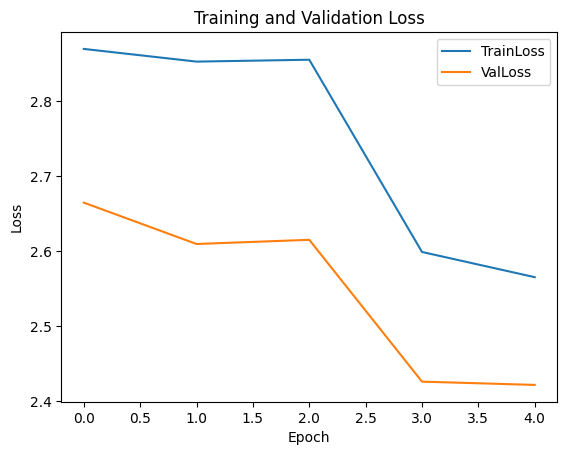

In [ ]:
# Train model
trainLosses, valLosses, valAccuracies = trainModel(model, trainLoader, valLoader, numEpochs=5)

# Plot Loss Curves
plt.plot(trainLosses, label='TrainLoss')
plt.plot(valLosses, label='ValLoss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
modelSavePath = "mobilenet_places365.pth"
torch.save(model.state_dict(), modelSavePath)
print(f"Model saved to: {modelSavePath}")

Model saved to: mobilenet_places365.pth


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluateModel(model, dataLoader, classNames):
    model.eval()
    allPreds = []
    allLabels = []

    with torch.no_grad():
        for xb, yb in dataLoader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            allPreds.extend(preds.cpu().numpy())
            allLabels.extend(yb.cpu().numpy())

    # Accuracy
    accuracy = sum(p == l for p, l in zip(allPreds, allLabels)) / len(allLabels)
    print(f"\n Evaluation Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(allLabels, allPreds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=classNames[:30], yticklabels=classNames[:30])  # plot only top 30 for visibility
    plt.title("Confusion Matrix (Top 30 Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\n Classification Report (Partial):")
    #print(classification_report(allLabels, allPreds, target_names=classNames[:10]))
    print(classification_report(allLabels, allPreds, target_names=classNames))




 Evaluation Accuracy: 0.4000


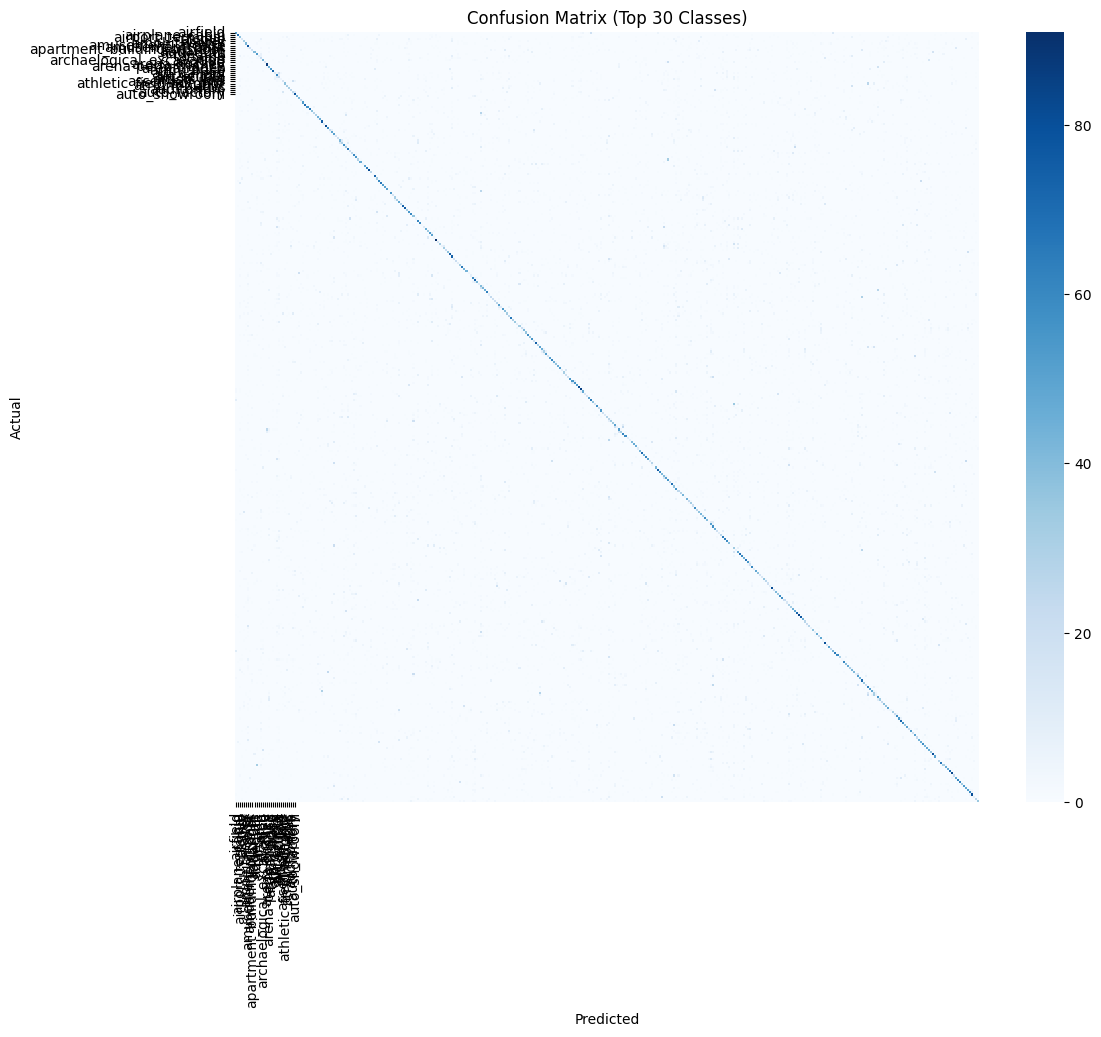


 Classification Report (Partial):
                            precision    recall  f1-score   support

                  airfield       0.60      0.50      0.55       100
            airplane_cabin       0.82      0.67      0.74       100
          airport_terminal       0.29      0.38      0.33       100
                    alcove       0.28      0.14      0.19       100
                     alley       0.42      0.32      0.36       100
              amphitheater       0.65      0.42      0.51       100
          amusement_arcade       0.32      0.78      0.46       100
            amusement_park       0.42      0.19      0.26       100
apartment_building-outdoor       0.23      0.18      0.20       100
                  aquarium       0.68      0.41      0.51       100
                  aqueduct       0.41      0.53      0.46       100
                    arcade       0.37      0.11      0.17       100
                      arch       0.15      0.22      0.18       100
  archaelogi

In [ ]:
# Evaluate model on validation data
evaluateModel(model, valLoader, trainDataset.classes)

